# IFN680 Assessment 3 — Aircraft Classification (Report Notebook)

**Student:** Karan Rooprai  **Student ID:** N12498122

This notebook **reproduces every figure and metric** used in the written report. It does **not**
retrain anything — it reloads the artefacts saved by `development.ipynb`
(`histories.pkl`, `best_model.pth`) and:

1. plots the learning curves for the baseline and the three experiments on shared graphs,
2. prints the validation-accuracy comparison table,
3. loads the best model, evaluates it on the untouched **test** set, and reports the required
   metric — **average per-class accuracy** — with a confusion matrix.

> Run `development.ipynb` first (it produces `histories.pkl` and `best_model.pth`), then run this
> notebook top-to-bottom.

## 1. Setup and load saved results

In [1]:
import os
import pickle

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from sklearn.metrics import (balanced_accuracy_score, confusion_matrix,
                             ConfusionMatrixDisplay)

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

with open('histories.pkl', 'rb') as f:
    saved = pickle.load(f)
histories   = saved['histories']
class_names = saved['class_names']
num_classes = len(class_names)
print("Loaded histories for:", list(histories.keys()))

Using device: cuda:0
Loaded histories for: ['baseline', 'aug', 'finetune', 'adamw', 'best']


## 2. Learning curves

The four models trained with a validation split — the baseline and the three experiments — are
overlaid on shared axes so their behaviour can be compared directly. Left: validation accuracy per
epoch. Right: training vs validation loss.

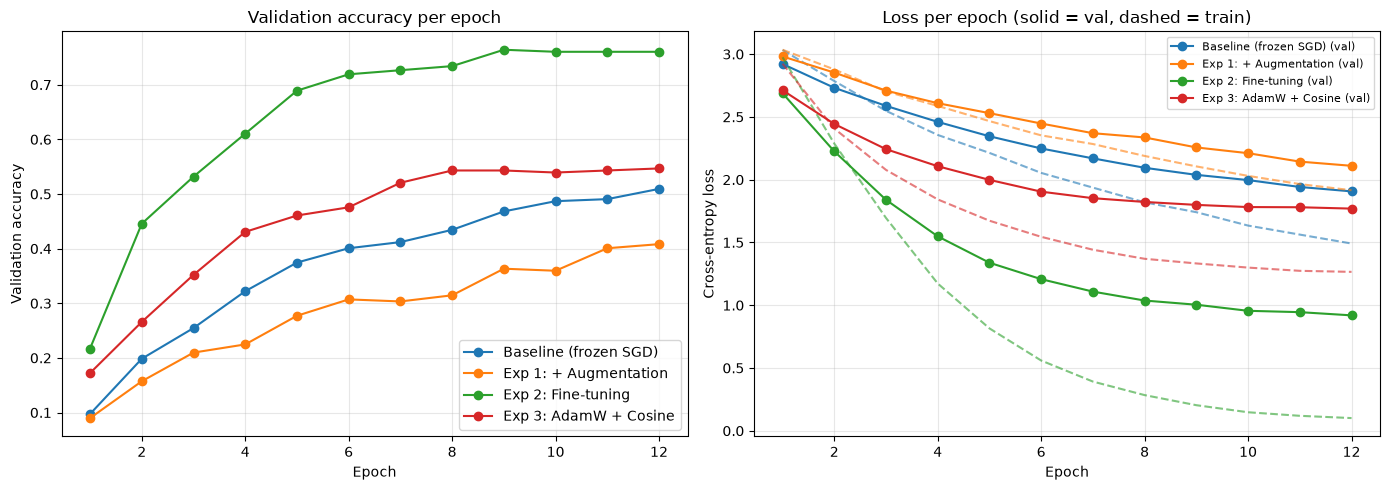

In [2]:
exp_keys = [('baseline', 'Baseline (frozen SGD)'),
            ('aug',      'Exp 1: + Augmentation'),
            ('finetune', 'Exp 2: Fine-tuning'),
            ('adamw',    'Exp 3: AdamW + Cosine')]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: validation accuracy for all four on one graph
for key, label in exp_keys:
    epochs = range(1, len(histories[key]['val_acc']) + 1)
    ax1.plot(epochs, histories[key]['val_acc'], marker='o', label=label)
ax1.set_title('Validation accuracy per epoch')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Validation accuracy')
ax1.grid(True, alpha=0.3); ax1.legend()

# Right: train (dashed) vs val (solid) loss for all four
for key, label in exp_keys:
    epochs = range(1, len(histories[key]['train_loss']) + 1)
    line, = ax2.plot(epochs, histories[key]['val_loss'], marker='o', label=f"{label} (val)")
    ax2.plot(epochs, histories[key]['train_loss'], linestyle='--',
             color=line.get_color(), alpha=0.6)
ax2.set_title('Loss per epoch (solid = val, dashed = train)')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Cross-entropy loss')
ax2.grid(True, alpha=0.3); ax2.legend(fontsize=8)

plt.tight_layout()
plt.savefig('learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Validation-accuracy comparison

Best validation accuracy reached by each model. The gap to the baseline shows how much each
design change contributed.

In [3]:
baseline_acc = histories['baseline']['best_val_acc']
print(f"{'Model':<28}{'Best val acc':>14}{'Δ vs baseline':>16}")
print('-' * 58)
for key, label in exp_keys:
    acc = histories[key]['best_val_acc']
    delta = acc - baseline_acc
    tag = '' if key == 'baseline' else f"{delta:+.4f}"
    print(f"{label:<28}{acc:>14.4f}{tag:>16}")

Model                         Best val acc   Δ vs baseline
----------------------------------------------------------
Baseline (frozen SGD)               0.5094                
Exp 1: + Augmentation               0.4082         -0.1011
Exp 2: Fine-tuning                  0.7640         +0.2547
Exp 3: AdamW + Cosine               0.5468         +0.0375


## 4. Best model — evaluation on the test set

The best model (fine-tuned ResNet-18, augmented training, AdamW + Cosine-Annealing, retrained on
all `trainval`) is reloaded from `best_model.pth` and evaluated **once** on the held-out test set.
The required metric is **average per-class accuracy** — the mean of the per-class recall values,
computed with `balanced_accuracy_score` — which is robust to any class imbalance in the test set.
The pass target is **> 0.75**.

In [4]:
# Rebuild the architecture and load the saved weights
imagenet_means = (0.485, 0.456, 0.406)
imagenet_stds  = (0.229, 0.224, 0.225)
eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize((224, 224)),
    transforms.Normalize(imagenet_means, imagenet_stds),
])

# Remove any hidden checkpoint folders before loading the test set
for root, dirs, files in os.walk('FGVCAircraft_Subset20'):
    for d in list(dirs):
        if d == '.ipynb_checkpoints':
            import shutil; shutil.rmtree(os.path.join(root, d))

test_dataset = torchvision.datasets.ImageFolder('FGVCAircraft_Subset20/test',
                                                transform=eval_transform)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

model = torchvision.models.resnet18(weights=None)
model.fc = nn.Linear(model.fc.in_features, num_classes)
model.load_state_dict(torch.load('best_model.pth', map_location=device))
model = model.to(device)
model.eval()
print("Loaded best_model.pth")

Loaded best_model.pth


In [5]:
all_labels, all_preds = [], []
with torch.no_grad():
    for inputs, targets in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        preds = torch.argmax(outputs, axis=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(targets.numpy())

all_labels = np.array(all_labels)
all_preds  = np.array(all_preds)

# Required metric: average per-class accuracy (= mean per-class recall)
avg_per_class_acc = balanced_accuracy_score(all_labels, all_preds)
overall_acc = (all_preds == all_labels).mean()

print(f"Overall test accuracy        : {overall_acc:.4f}")
print(f"Average per-class accuracy   : {avg_per_class_acc:.4f}   (target > 0.75)")
print("PASS" if avg_per_class_acc > 0.75 else "BELOW TARGET")

Overall test accuracy        : 0.8774
Average per-class accuracy   : 0.8775   (target > 0.75)
PASS


### 4.1 Confusion matrix and per-class accuracy

The confusion matrix shows where the model confuses visually similar aircraft; the per-class
accuracy list identifies the weakest classes.

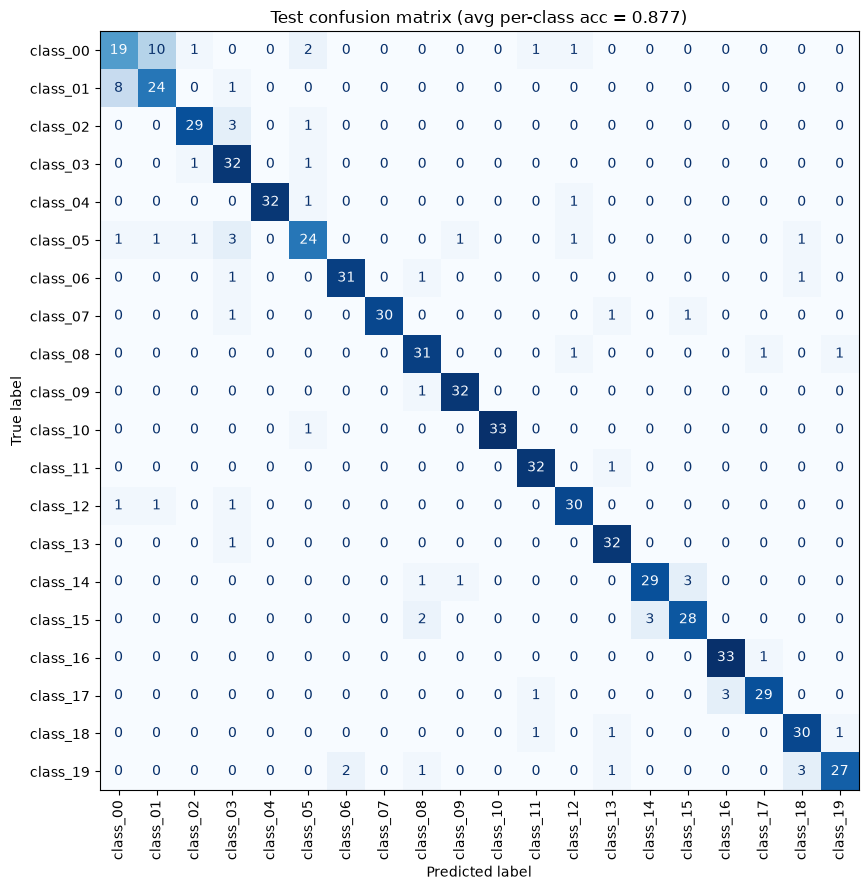

In [6]:
cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(10, 9))
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(
    ax=ax, xticks_rotation='vertical', colorbar=False, cmap='Blues')
ax.set_title(f'Test confusion matrix (avg per-class acc = {avg_per_class_acc:.3f})')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
# Per-class accuracy = diagonal / row sum
per_class = cm.diagonal() / cm.sum(axis=1)
order = np.argsort(per_class)
print(f"{'Class':<12}{'Accuracy':>10}")
print('-' * 22)
for i in order:
    print(f"{class_names[i]:<12}{per_class[i]:>10.3f}")
print('-' * 22)
print(f"{'MEAN':<12}{per_class.mean():>10.3f}")

Class         Accuracy
----------------------
class_00         0.559
class_01         0.727
class_05         0.727
class_19         0.794
class_15         0.848
class_14         0.853
class_17         0.879
class_02         0.879
class_07         0.909
class_18         0.909
class_12         0.909
class_06         0.912
class_08         0.912
class_04         0.941
class_03         0.941
class_09         0.970
class_11         0.970
class_13         0.970
class_10         0.971
class_16         0.971
----------------------
MEAN             0.877
